# Log Transformation

Log Transformation is a feature transformation technique used to transform numerical data by applying a logarithmic function.

It is especially useful for:

- Right-skewed data
- Highly skewed numerical features
- Features with very large values
- Reducing the influence of extreme values

A common transformation is:

x_transformed = log(1 + x)

Using `log1p(x)` is useful because it can safely handle zero values.

## Why Do We Need Log Transformation?

Many real-world numerical features are highly right-skewed.

Examples include:

- Income
- Salary
- Population
- House prices
- Number of followers
- Website visits
- Sales

A small number of observations may have extremely large values.

Log Transformation compresses large values and can make the distribution more balanced.

In [1]:
import pandas as pd

df = pd.DataFrame({
    "Income": [
        20000,
        25000,
        30000,
        35000,
        40000,
        50000,
        70000,
        100000,
        200000,
        1000000
    ]
})

df

,Income
0,20000
1,25000
2,30000
3,35000
4,40000
5,50000
6,70000
7,100000
8,200000
9,1000000


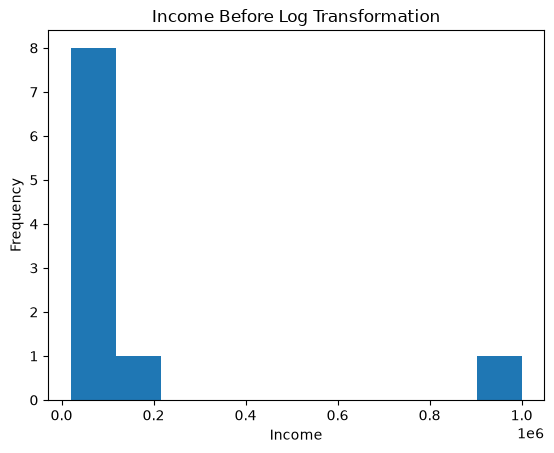

In [2]:
import matplotlib.pyplot as plt

plt.hist(df["Income"], bins=10)

plt.title("Income Before Log Transformation")
plt.xlabel("Income")
plt.ylabel("Frequency")

plt.show()

## Measuring Skewness

Skewness tells us how asymmetric a distribution is.

A positive skewness indicates a distribution with a longer right tail.

Log Transformation is commonly useful for reducing positive/right skewness.

In [3]:
print("Skewness:", df["Income"].skew())

Skewness: 2.986903171463433


## Manual Log Transformation

We can apply the natural logarithm using NumPy.

For data containing zero values, we commonly use:

log(1 + x)

This is equivalent to NumPy's:

`np.log1p(x)`

In [4]:
import numpy as np

df["Income_Log"] = np.log1p(df["Income"])

df

,Income,Income_Log
0,20000,9.903538
1,25000,10.126671
2,30000,10.308986
3,35000,10.463132
4,40000,10.596660
5,50000,10.819798
6,70000,11.156265
7,100000,11.512935
8,200000,12.206078
9,1000000,13.815512


In [5]:
df[["Income", "Income_Log"]]

,Income,Income_Log
0,20000,9.903538
1,25000,10.126671
2,30000,10.308986
3,35000,10.463132
4,40000,10.596660
5,50000,10.819798
6,70000,11.156265
7,100000,11.512935
8,200000,12.206078
9,1000000,13.815512


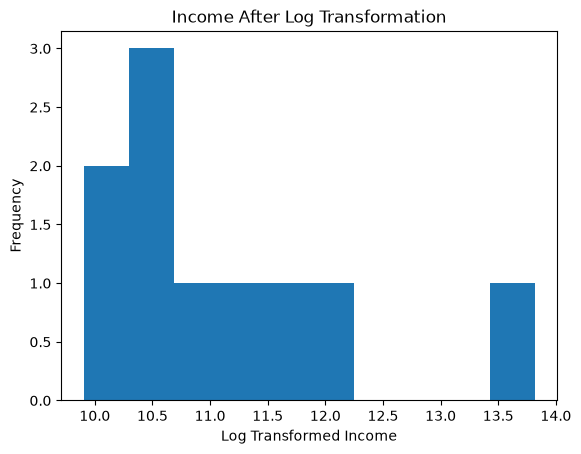

In [6]:
plt.hist(df["Income_Log"], bins=10)

plt.title("Income After Log Transformation")
plt.xlabel("Log Transformed Income")
plt.ylabel("Frequency")

plt.show()

In [7]:
print("Original Skewness:")
print(df["Income"].skew())

print("\nLog Transformed Skewness:")
print(df["Income_Log"].skew())

Original Skewness:
2.986903171463433

Log Transformed Skewness:
1.5462545306092266


## Handling Zero Values

The normal logarithm cannot be calculated for zero:

log(0) → undefined

Therefore, when a feature contains zero values, we can use:

log(1 + x)

For example:

0 → log(1 + 0) = 0

NumPy provides `np.log1p()` specifically for this transformation.

In [9]:
df_zero = pd.DataFrame({
    "Sales": [0, 10, 20, 50, 100, 500, 1000]
})

df_zero["Sales_Log"] = np.log1p(df_zero["Sales"])

df_zero

,Sales,Sales_Log
0,0,0.000000
1,10,2.397895
2,20,3.044522
3,50,3.931826
4,100,4.615121
5,500,6.216606
6,1000,6.908755


## Using Scikit-Learn

Scikit-learn provides `FunctionTransformer`, which allows us to apply mathematical transformations such as logarithms inside a machine learning preprocessing pipeline.

In [10]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(
    np.log1p
)

df_zero["Sales_Log_Sklearn"] = (
    log_transformer.fit_transform(
        df_zero[["Sales"]]
    )
)

df_zero

,Sales,Sales_Log,Sales_Log_Sklearn
0,0,0.000000,0.000000
1,10,2.397895,2.397895
2,20,3.044522,3.044522
3,50,3.931826,3.931826
4,100,4.615121,4.615121
5,500,6.216606,6.216606
6,1000,6.908755,6.908755
